<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/RNN_Model_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Building a SimpleRNN Model for Weather Temperature Prediction
Objective
The goal of this assignment is to design, implement, and evaluate a Recurrent Neural Network
(RNN) model (using SimpleRNN) to forecast the next day’s temperature based on past weather
data.

Dataset
Use the Daily Weather Dataset
● Example: Daily Weather Dataset – Kaggle
● Key Features:
○ Date
○ Temperature (target variable)
○ Humidity
○ Wind Speed
○ Pressure (optional)

Tasks
Part A: Data Understanding and Preprocessing
1. Load the dataset and explore:
○ Display first 10 rows.
○ Plot temperature trends over time.
○ Check for missing values.

--- First 10 Rows ---
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   
5  2006-04-01 05:00:00.000 +0200  Partly Cloudy        rain         9.222222   
6  2006-04-01 06:00:00.000 +0200  Partly Cloudy        rain         7.733333   
7  2006-04-01 07:00:00.000 +0200  Partly Cloudy        rain         8.772222   
8  2006-04-01 08:00:00.000 +0200  Partly Cloudy        rain        10.822222   
9  2006-04-01 09:00:00.000 +0200  Partly Cloudy        rain        13.772222   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89

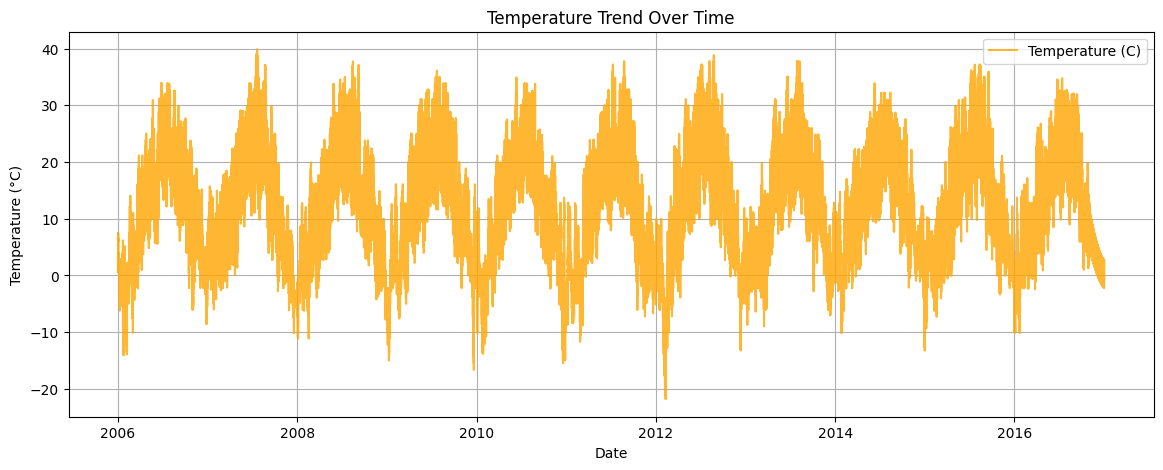

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# 1. Load Dataset & Exploration
df = pd.read_csv('weatherHistory.csv')

print("--- First 10 Rows ---")
print(df.head(10))

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df = df.sort_values('Formatted Date').reset_index(drop=True)

# Plot Temperature Trend
plt.figure(figsize=(14, 5))
plt.plot(df['Formatted Date'], df['Temperature (C)'], label='Temperature (C)', color='orange', alpha=0.8)
plt.title('Temperature Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


2. Preprocess the data:
○ Handle missing values (impute/remove).
○ Normalize values using MinMaxScaler (so RNN converges faster).
○ Create input sequences:
■ Use past 7–14 days’ weather data (temperature, humidity, wind speed)
as input.
■ Target: next day’s temperature.
○ Split dataset into train, validation, and test sets.

In [3]:
# 2. Data Preprocessing
# Select key features: Temperature (C), Humidity, Wind Speed (km/h)
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
df_clean = df[features].copy()

# Handle missing values if any
df_clean = df_clean.fillna(method='ffill')

# Normalize features using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_clean)

# Scaler specifically for inverse transforming temperature target values
temp_scaler = MinMaxScaler(feature_range=(0, 1))
temp_scaler.fit(df_clean[['Temperature (C)']])

# Function to create input sequence windows (Lookback = 10 days)
def create_sequences(data, sequence_length=10):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i : i + sequence_length])
        # Target variable is Temperature (index 0 in features)
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

SEQ_LENGTH = 10
X, y = create_sequences(scaled_data, sequence_length=SEQ_LENGTH)

# Train, Validation, and Test Split (Chronological split: 70% Train, 15% Val, 15% Test)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"\nData Shapes -> X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


/tmp/ipykernel_1817/3519549616.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method='ffill')



Data Shapes -> X_train: (67510, 10, 3), X_val: (14466, 10, 3), X_test: (14467, 10, 3)


Part B: RNN Model Development
3. Build a SimpleRNN model using TensorFlow/Keras:
○ Input layer (with shape = sequence length × number of features).
○ SimpleRNN layer (e.g., 32–64 units).
○ Dropout layer (optional, to avoid overfitting).
○ Dense layer with 1 unit (linear activation for regression).

In [4]:
# 3. Model Architecture
num_features = X_train.shape[2]

model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(SEQ_LENGTH, num_features), return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Linear activation for regression
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
# 4. Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,409 (21.13 KB)

 Trainable params: 5,409 (21.13 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 5. Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 4.5906e-04 - mae: 0.0156 - val_loss: 3.6984e-04 - val_mae: 0.0148
Epoch 2/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 4.6234e-04 - mae: 0.0156 - val_loss: 3.8141e-04 - val_mae: 0.0151
Epoch 3/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 4.5976e-04 - mae: 0.0156 - val_loss: 3.9747e-04 - val_mae: 0.0156
Epoch 4/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 4.5941e-04 - mae: 0.0156 - val_loss: 3.2633e-04 - val_mae: 0.0137
Epoch 5/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 4.5771e-04 - mae: 0.0156 - val_loss: 3.3628e-04 - val_mae: 0.0142
Epoch 6/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 4.5487e-04 - mae: 0.0155 - val_loss: 2.9264e-04 - val_mae: 0.0130
Epoch 7/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 4.6005e-04 - mae: 0.0156 - val_loss: 3.7716e-04 - val_mae: 0.0153
Epoch 8/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 4.5716e-04 - mae: 0.0155 - val_los

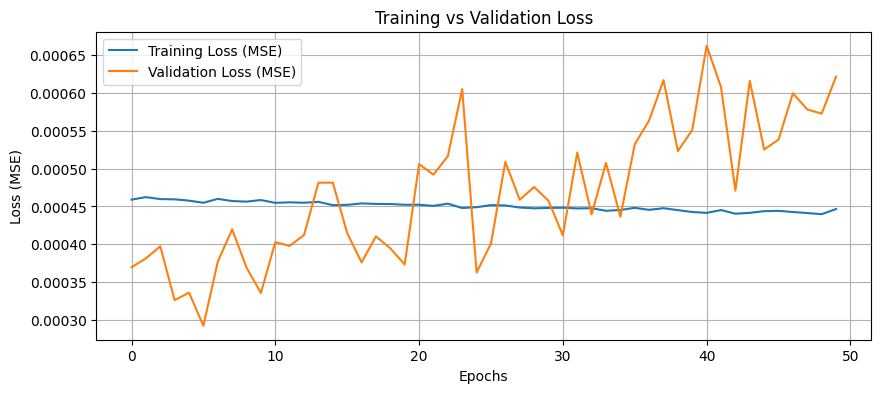

In [10]:
# Plot Loss Curves
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Part C: Model Evaluation & Forecasting
6. Evaluate the model on the test set:
○ Calculate RMSE, MAE, and R2 score.
○ Plot predicted vs actual temperatures for the test period.
7. Forecast the next 7 days of temperature using the trained model and visualize
predictions vs recent historical data.

453/453 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

--- Model Test Evaluation ---
Root Mean Squared Error (RMSE): 1.7653 °C
Mean Absolute Error (MAE):     1.4204 °C
R² Score:                       0.9635


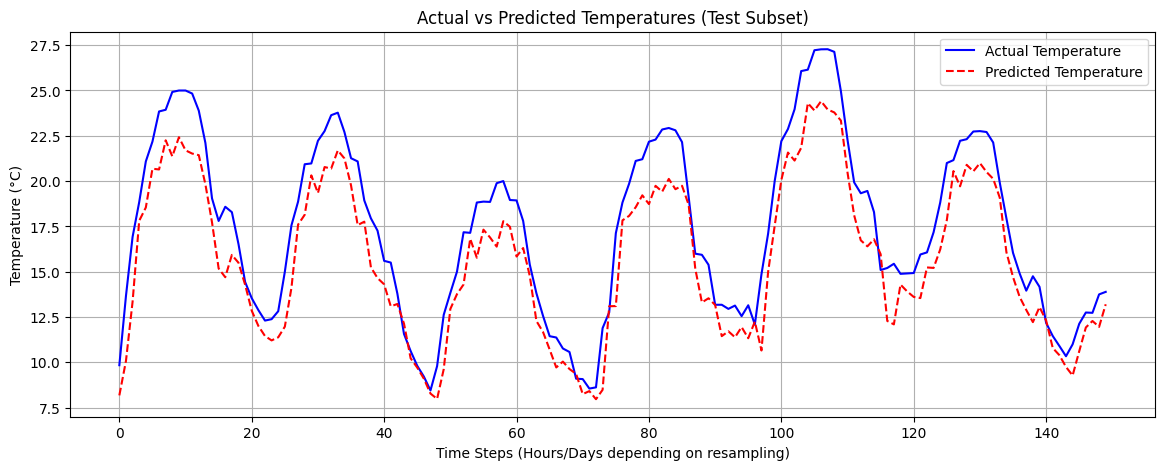

In [11]:
# 6. Evaluate on Test Set
y_pred_scaled = model.predict(X_test)

# Rescale predictions and ground truth back to original °C scale
y_test_orig = temp_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_orig = temp_scaler.inverse_transform(y_pred_scaled)

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print("\n--- Model Test Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} °C")
print(f"Mean Absolute Error (MAE):     {mae:.4f} °C")
print(f"R² Score:                       {r2:.4f}")

# Plot Predicted vs Actual Temperatures (Sample of 150 points for visual clarity)
plt.figure(figsize=(14, 5))
plt.plot(y_test_orig[:150], label='Actual Temperature', color='blue')
plt.plot(y_pred_orig[:150], label='Predicted Temperature', color='red', linestyle='--')
plt.title('Actual vs Predicted Temperatures (Test Subset)')
plt.xlabel('Time Steps (Hours/Days depending on resampling)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

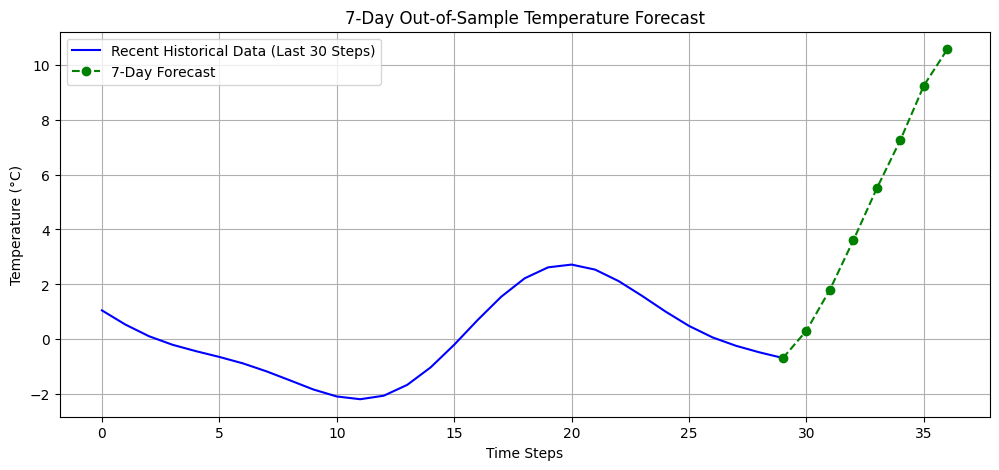

In [13]:
# 7. Autoregressive 7-Day Iterative Forecast
# Create combined y-data array (1 last point + 7 forecast points = 8 total)
forecast_plot_data = np.vstack([recent_actuals[-1:], forecast_orig])

# Plot using matching x and y dimensions
plt.figure(figsize=(12, 5))
plt.plot(range(0, 30), recent_actuals, label='Recent Historical Data (Last 30 Steps)', color='blue')
plt.plot(
    range(29, 29 + len(forecast_plot_data)),
    forecast_plot_data,
    label='7-Day Forecast',
    color='green',
    marker='o',
    linestyle='--'
)
plt.title('7-Day Out-of-Sample Temperature Forecast')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()